# Customer Sentiment Analysis

## (1) Import Libraries & Setup

In [57]:
# Core libraries
import numpy as np
import pandas as pd
import re
import string
import os
import warnings
warnings.filterwarnings('ignore')

# NLP preprocessing (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Visualisation & text exploration
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Machine learning utilities (Sklearn)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Feature engineering (Text Vectorisation)
from sklearn.feature_extraction.text import TfidfVectorizer

# Classical machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    log_loss
)

# Deep learning (PyTorch for BERT)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers (BERT)
from transformers import BertTokenizer, BertForSequenceClassification

# Environment Settings
# Ignore unnecessary Hugging Face warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## (2) Data Loading & Overview

In [3]:
df = pd.read_csv('C:/Users/user/Python Projects/emotion_sentimen_dataset.csv')

In [4]:
# Data overview
print(df.head())
print(df.info())

   Unnamed: 0                                               text  Emotion
0           0  i seriously hate one subject to death but now ...     hate
1           1                 im so full of life i feel appalled  neutral
2           2  i sit here to write i start to dig out my feel...  neutral
3           3  ive been really angry with r and i feel like a...    anger
4           4  i feel suspicious if there is no one outside l...  neutral
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839555 entries, 0 to 839554
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  839555 non-null  int64 
 1   text        839555 non-null  object
 2   Emotion     839555 non-null  object
dtypes: int64(1), object(2)
memory usage: 19.2+ MB
None


In [5]:
# Mapping dictionary is described for transforming values
emotion_to_sentiment = {
    'joy': 'positive',
    'love': 'positive',
    'surprise': 'positive',
    'happy': 'positive',
    'anger': 'negative',
    'hate': 'negative',
    'sadness': 'negative',
    'fear': 'negative',
    'disgust': 'negative',
    'neutral': 'neutral'
}

# implement mapping
df['Sentiment'] = df['Emotion'].map(emotion_to_sentiment)

# drop the rows where maping could not suceed, example: unknown emotion
df = df.dropna(subset=['Sentiment'])

# prints the distribution
print(df['Sentiment'].value_counts())

Sentiment
neutral     674538
positive     46507
negative     45084
Name: count, dtype: int64


##### The mapping from emotions to sentiment classes reveals three categories: positive, neutral, and negative. However, there is a class imbalance, with neutral comments significantly outnumbering positive and negative ones.

In [6]:
# Some initial data cleaning
df = df[['text', 'Sentiment']].copy()
df = df.dropna().drop_duplicates()
df['text'] = df['text'].str.strip()
df['Sentiment'] = df['Sentiment'].str.strip().str.lower()
df = df.reset_index(drop=True)

In [7]:
# Overview of the cleaned dataset
print(df.info())

df = df.reset_index(drop=True)

print("Dataset has been cleaned now.")
print(f"Dataset shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358596 entries, 0 to 358595
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       358596 non-null  object
 1   Sentiment  358596 non-null  object
dtypes: object(2)
memory usage: 5.5+ MB
None
Dataset has been cleaned now.
Dataset shape: (358596, 2)


## (3) Exploratory Data Analysis (EDA)

In [8]:
# Analysing and distributing sentiment values 
print("\nSentiment allocation:")
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)
print("\nPercentage allocation:")
print(df['Sentiment'].value_counts(normalize=True).round(3) * 100)


Sentiment allocation:
Sentiment
neutral     316935
positive     21064
negative     20597
Name: count, dtype: int64

Percentage allocation:
Sentiment
neutral     88.4
positive     5.9
negative     5.7
Name: proportion, dtype: float64


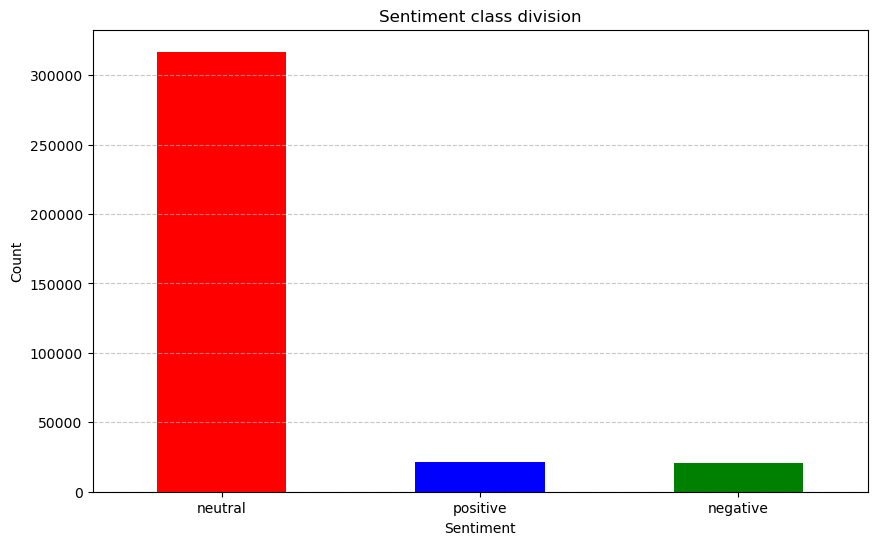

In [9]:
# Bar chart of Sentiment class
plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Sentiment class division')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

([<matplotlib.patches.Wedge at 0x19deb213b60>,
 [Text(-1.0275423462369115, 0.39262797492020757, 'neutral'),
  Text(0.9403944441453109, -0.570664778500156, 'positive'),
  Text(1.0821400337056515, -0.1974156717475377, 'negative')])

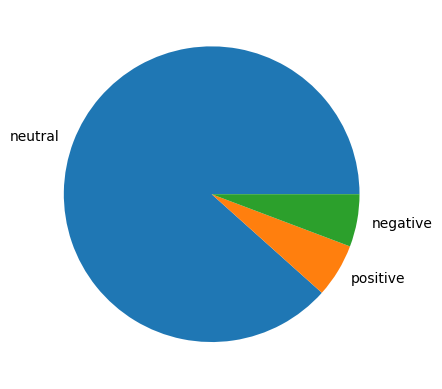

In [10]:
# Pie chart of Sentiment class
plt.pie(df.Sentiment.value_counts(), labels = df.Sentiment.value_counts().index)

##### The dataset is highly imbalanced, with the neutral category making up most samples. This imbalance may lead the model to bias towards predicting the majority class.

In [11]:
# Analysing the text length in the dataset
df['text_length'] = df['text'].str.split().str.len()
print("\nText length statistics:")
print(df['text_length'].describe().round(2))


Text length statistics:
count    358596.00
mean         18.88
std          10.91
min           1.00
25%          10.00
50%          17.00
75%          25.00
max         178.00
Name: text_length, dtype: float64


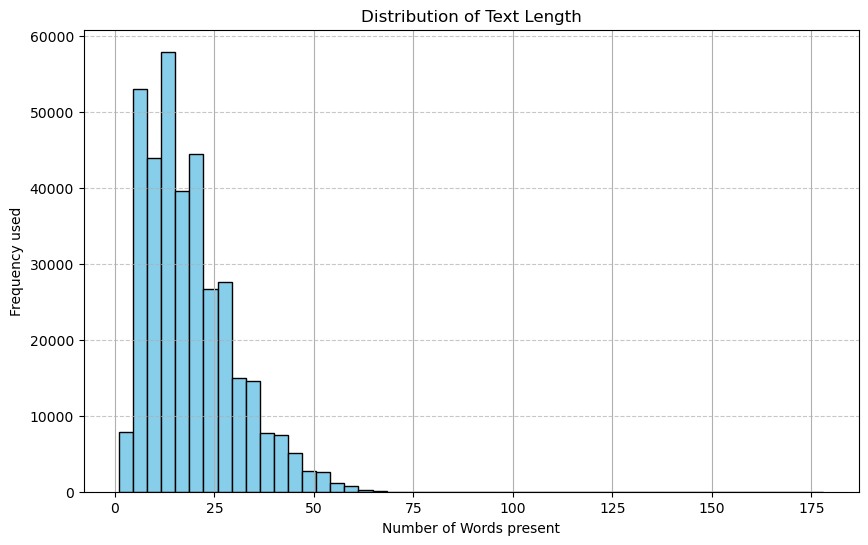

In [12]:
# Visualises text length distribution using histogram
plt.figure(figsize=(10, 6))
df['text_length'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Length')
plt.xlabel('Number of Words present')
plt.ylabel('Frequency used')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

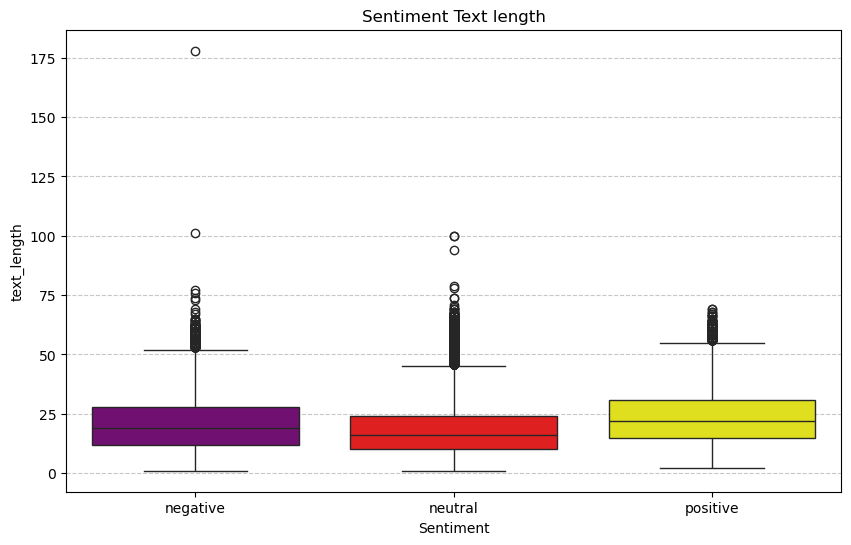

In [13]:
# Visualises the distribution of text lengths for each sentiment class
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sentiment', y='text_length', data=df, hue='Sentiment', palette=['purple', 'red', 'yellow'], legend=False)
plt.title('Sentiment Text length')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### The figure shows that positive sentiment texts are typically longer than negative and neutral ones. Despite an unbalanced dataset with neutral being the most frequent, users express positive emotions in more detail. This may influence the model to prefer longer texts associated with positive sentiment.

In [14]:
# Display sample texts of each sentiment class
print("\nSome sample texts are given from each sentiment class:")
for sentiment in df['Sentiment'].unique():
    print(f"\n{sentiment.upper()} example:")
    print(df[df['Sentiment'] == sentiment]['text'].iloc[0])


Some sample texts are given from each sentiment class:

NEGATIVE example:
i seriously hate one subject to death but now i feel reluctant to drop it

NEUTRAL example:
im so full of life i feel appalled

POSITIVE example:
i feel jealous becasue i wanted that kind of love the true connection between two souls and i wanted that


##### Positive texts are more expressive, neutral texts are brief, and negative texts focus solely on negative emotions.

In [15]:
# Finds the most unique and common words from each class
for sentiment in df['Sentiment'].unique():
    words = ' '.join(df[df['Sentiment'] == sentiment]['text']).split()
    common_words = Counter(words).most_common(10)
    print(f"\nUsual words present in {sentiment} sentiment:")
    for word, count in common_words:
        print(f"{word}: {count}")


Usual words present in negative sentiment:
i: 37021
and: 15826
feel: 13500
to: 11908
the: 11027
feeling: 8288
a: 7649
that: 7272
of: 6921
my: 5440

Usual words present in neutral sentiment:
i: 499756
feel: 220197
and: 173667
to: 169316
the: 156692
a: 122417
feeling: 100493
that: 94608
of: 93936
my: 79799

Usual words present in positive sentiment:
i: 40152
and: 18214
feel: 15182
the: 14650
to: 14113
love: 11254
a: 9319
that: 8876
of: 8626
my: 7637


##### The examples show that words like 'I,' 'my,' 'feel,' and 'and' appear in all three classes, reflecting a personal and emotional tone. This overlap indicates that the model must consider context and word combinations, rather than relying solely on keywords, to distinguish sentiment.

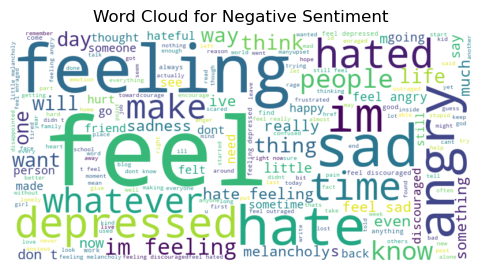

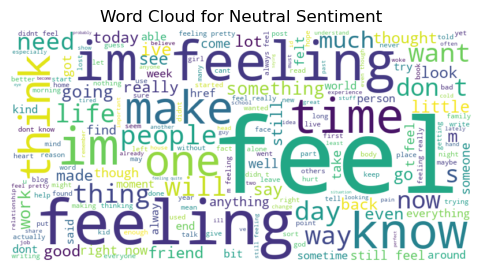

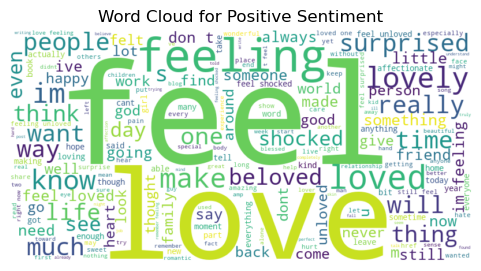

In [16]:
# Creating word clouds for all the three sentiment class seperately
for sentiment in df['Sentiment'].unique():
    text = ' '.join(df[df['Sentiment'] == sentiment]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(6, 3))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment.capitalize()} Sentiment')
    plt.show()

##### A word cloud visually identifies vocabulary in sentiment classes. The figure shows that 'feel' is the most common word across all three classes, linked to emotions.

## (4) Data Division

In [17]:
# Data is split into training and test for analysis
X = df['text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data size: {len(X_train)}")
print(f"Test data size: {len(X_test)}")
print("\nTraining data:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print("\nTest data:")
print(y_test.value_counts(normalize=True).round(3) * 100)
labels = sorted(y_test.unique())

Training data size: 286876
Test data size: 71720

Training data:
Sentiment
neutral     88.4
positive     5.9
negative     5.7
Name: proportion, dtype: float64

Test data:
Sentiment
neutral     88.4
positive     5.9
negative     5.7
Name: proportion, dtype: float64


## (5) Text Preprocessing

In [18]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # change text to lowercase
    text = text.lower()
    
    # delete the URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # delete the HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove the punctuations present
    text = re.sub(r'[^\w\s]', '', text)
    
    # eliminate the numbers
    text = re.sub(r'\d+', '', text)
    
    # eliminate the extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize the text
    tokens = text.split()
    
    # remove the stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

X_train_clean = X_train.apply(preprocess)
X_test_clean = X_test.apply(preprocess)

# display 3 set of samples
for i in range(3):
    print(f"\nSample {i+1}:")
    print("Original text:")
    print(X_train.iloc[i])
    print("\nProcessed text:")
    print(X_train_clean.iloc[i])
    print("-" * 80)   #seperate the samples


Sample 1:
Original text:
reading literature on aidshomosexuality

Processed text:
reading literature aidshomosexuality
--------------------------------------------------------------------------------

Sample 2:
Original text:
i feel like ea completely ignored the feedback from their fan base and said we are giving you the game we made whether you like it or not

Processed text:
feel like ea completely ignored feedback fan base said giving game made whether like
--------------------------------------------------------------------------------

Sample 3:
Original text:
im going to cover this games most fatal flaw there is simply no substance to back it all up and the amount of structure feels marginally low

Processed text:
im going cover game fatal flaw simply substance back amount structure feel marginally low
--------------------------------------------------------------------------------


## (6) Feature Engineering

In [19]:
#TF-IDF feature extraction
vectorizer = TfidfVectorizer(max_features=5000)  # initialise vectorizer
X_train_vec = vectorizer.fit_transform(X_train_clean)  #fit and transform the text in training data
X_test_vec = vectorizer.transform(X_test_clean)        #transform the test data

print(f"The altered TF-IDF training data shape: {X_train_vec.shape}")
print(f"The altered TF-IDF test data shape: {X_test_vec.shape}")
print(f"Number of attributes present: {len(vectorizer.get_feature_names_out())}")

The altered TF-IDF training data shape: (286876, 5000)
The altered TF-IDF test data shape: (71720, 5000)
Number of attributes present: 5000


##### TF-IDF feature extraction is performed to transform texts into numerical features for use in support vector machines (SVM).

## (7) Model Training and Hyperparameter Tuning

### (7a) SVM Model

In [47]:
# Grid search on vectorised data
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10]
}

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=3000
)

grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_vec, y_train)

print(" Best Parameters:", grid_svm.best_params_)
print(f" Best CV Score: {grid_svm.best_score_:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
 Best Parameters: {'C': 1}
 Best CV Score: 0.9919


In [46]:
# Model
best_svm = grid_svm.best_estimator_

svm_final = CalibratedClassifierCV(best_svm, cv=3)
svm_final.fit(X_train_vec, y_train)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=1...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or 

In [45]:
# Prediction
y_pred = svm_final.predict(X_test_vec)
y_proba = svm_final.predict_proba(X_test_vec)

In [44]:
# Evaluation
print("Tuned SVM Performance")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba):.4f}")

Tuned SVM Performance
              precision    recall  f1-score   support

    negative       1.00      0.97      0.98      4119
     neutral       1.00      1.00      1.00     63388
    positive       1.00      0.99      0.99      4213

    accuracy                           1.00     71720
   macro avg       1.00      0.99      0.99     71720
weighted avg       1.00      1.00      1.00     71720

Accuracy: 0.9977
F1 Score (weighted): 0.9977
Log Loss: 0.0190


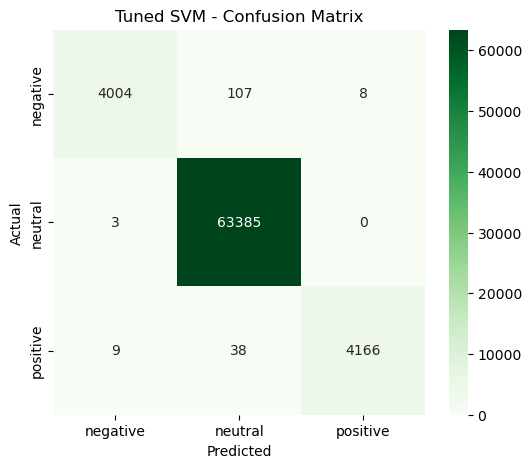

In [43]:
# Confusion Matrix
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)

plt.title('Tuned SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##### The tuned SVM achieves near-perfect performance (accuracy: 99.77%) with consistently high precision, recall, and F1-scores across all classes. Strong weighted F1 (~0.99–1.00) and low log loss (0.019) indicate robust and well-calibrated predictions despite class imbalance.

### (7b) BERT Model

In [37]:
# Data preparation (Sampling + Encoding)

# Reduce dataset size (BERT is computationally expensive)
df_bert = df.sample(n=1000, random_state=42).reset_index(drop=True)

# Encode sentiment labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_bert['label'] = le.fit_transform(df_bert['Sentiment'])

# Train-validation split
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_bert['text'],
    df_bert['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_bert['label']
)


In [39]:
# Class Weights (Handling Imbalance)
class_names = np.unique(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_names,
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [40]:
# Tokenisation + Dataset
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# DataLoaders
train_dataset = EmotionDataset(train_texts, train_labels, tokenizer)
val_dataset = EmotionDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

##### Text data is tokenised into BERT-compatible inputs, enabling the model to process contextual word representations. 

In [49]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_labels = len(le.classes_)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
)

model = model.to(device)

# Loss + optimizer
class_weights = class_weights.to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##### These warnings are expected when fine-tuning BERT on a new task. The main model uses pre-trained weights, while the classification layer is newly initialised and trained on our dataset.

In [50]:
# Training loop
epochs = 3 # using 3 epochs as BERT is usually fine-tuned in between 2 to 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}: Training Loss = {avg_train_loss:.4f}")

Epoch 1: Training Loss = 1.0289
Epoch 2: Training Loss = 0.8215
Epoch 3: Training Loss = 0.3992


In [51]:
# Model evaluation
model.eval()

all_preds = []
all_labels = []
val_loss = 0
num_batches = 0

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        logits = outputs.logits
        loss = outputs.loss

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        val_loss += loss.item()
        num_batches += 1

avg_val_loss = val_loss / num_batches

print("Classification Report:\n", classification_report(all_labels, all_preds))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score (weighted): {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Validation Loss: {avg_val_loss:.4f}")

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.58      0.42        12
           1       0.96      0.83      0.89       177
           2       0.35      0.82      0.49        11

    accuracy                           0.81       200
   macro avg       0.55      0.74      0.60       200
weighted avg       0.89      0.81      0.84       200

Accuracy: 0.8150
F1 Score (weighted): 0.8407
Validation Loss: 0.4828


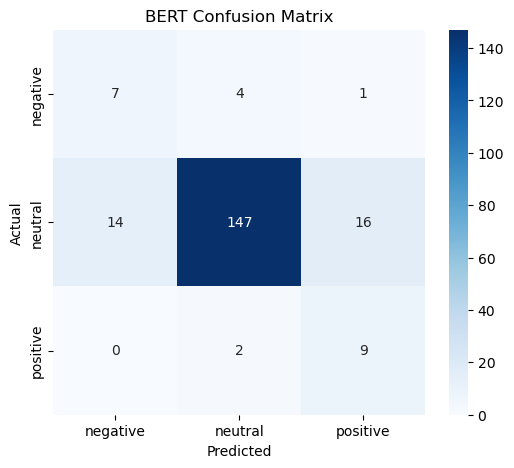

In [52]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('BERT Confusion Matrix')
plt.show()

## (8) Model comparison

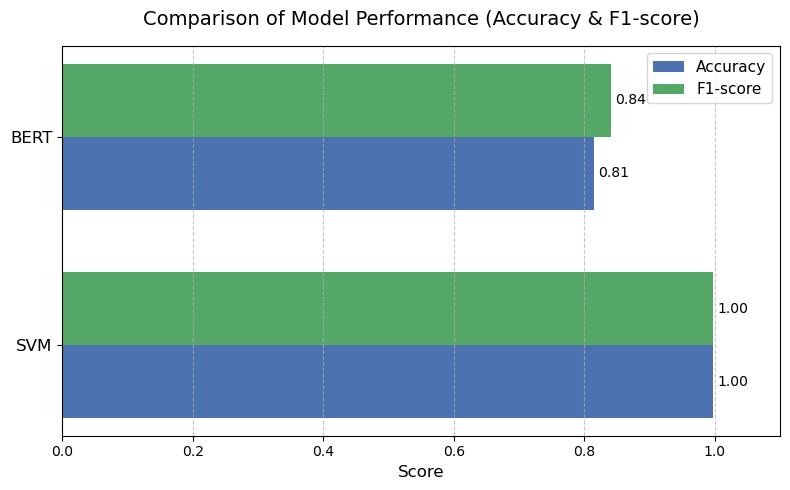

In [55]:
## (8) Model comparison
models = ['SVM', 'BERT']
accuracy = [0.9977, 0.8150]
f1 = [0.9977, 0.8407]

y = np.arange(len(models))
height = 0.35  # bar height

fig, ax = plt.subplots(figsize=(8,5))

# Plot horizontal bars
bars1 = ax.barh(y - height/2, accuracy, height, label='Accuracy', color='#4C72B0')
bars2 = ax.barh(y + height/2, f1, height, label='F1-score', color='#55A868')

# Add data labels
for bar in bars1 + bars2:
    width = bar.get_width()
    ax.annotate(f'{width:.2f}',
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(3,0),
                textcoords='offset points',
                ha='left', va='center', fontsize=10)

# Customize chart
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=12)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('Comparison of Model Performance (Accuracy & F1-score)', fontsize=14, pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

##### The chart shows that SVM significantly outperforms BERT, achieving near-perfect accuracy and F1-score. BERT performs reasonably well but lags behind, likely due to limited training data and higher model complexity.